In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")                      # run everything from the project root
sys.path.insert(0, os.getcwd())

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
pd.set_option("display.max_columns", 50)

# 03 · Feature Engineering
We turn raw counts into behavioural features that describe *how* a visitor browsed.

In [2]:
from src.feature_engineering import add_features, get_cluster_matrix, CLUSTER_FEATURES
from src.clustering import scale_features

df = pd.read_csv('data/processed/visitors_cleaned.csv')
feats = add_features(df)
new = ['TotalPages','TotalDuration','AvgTimePerPage','ProductPageShare','ProductTimeShare','IsNewVisitor','IsReturning']
feats[new].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalPages,12205.0,34.893240,46.627336,0.0,9.000000,20.000000,42.000000,746.00000
TotalDuration,12205.0,1323.454242,2043.871589,0.0,231.666667,690.958333,1643.958333,69921.64723
AvgTimePerPage,12205.0,38.179096,43.472877,0.0,18.555556,29.970787,45.688278,1411.00000
ProductPageShare,12205.0,0.904126,0.142281,0.0,0.857143,0.961538,1.000000,1.00000
ProductTimeShare,12205.0,0.851437,0.255850,0.0,0.831101,0.968646,1.000000,1.00000
IsNewVisitor,12205.0,0.138714,0.345662,0.0,0.000000,0.000000,0.000000,1.00000
IsReturning,12205.0,0.854650,0.352468,0.0,1.000000,1.000000,1.000000,1.00000


### Why log-transform?

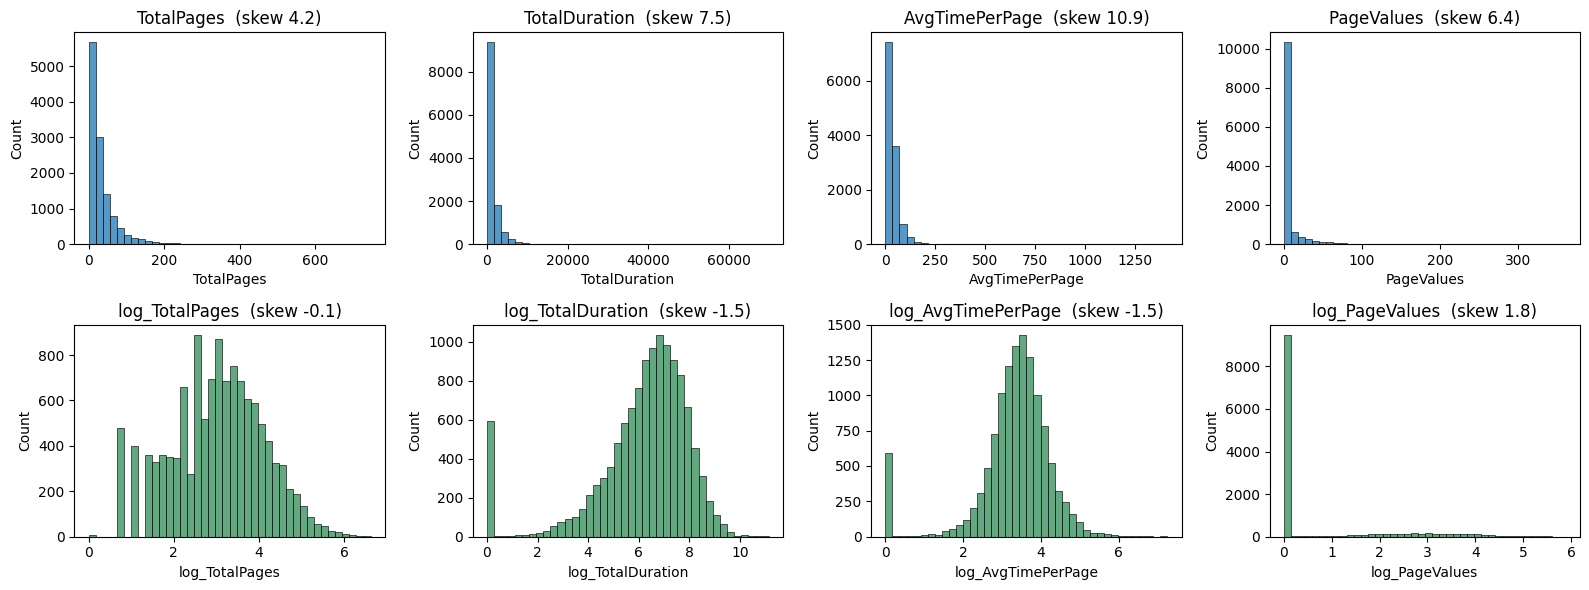

In [3]:
cols = ['TotalPages','TotalDuration','AvgTimePerPage','PageValues']
fig, ax = plt.subplots(2, 4, figsize=(16, 6))
for i, c in enumerate(cols):
    sns.histplot(feats[c], bins=40, ax=ax[0, i]).set_title(f'{c}  (skew {feats[c].skew():.1f})')
    sns.histplot(feats['log_'+c], bins=40, ax=ax[1, i], color='seagreen').set_title(f'log_{c}  (skew {feats['log_'+c].skew():.1f})')
plt.tight_layout(); plt.show()

### Final clustering features
`Revenue` is **excluded** so that segments reflect behaviour only; we use it afterwards to validate them.

['log_TotalPages', 'log_TotalDuration', 'log_AvgTimePerPage', 'ProductPageShare', 'BounceRates', 'ExitRates', 'log_PageValues', 'IsNewVisitor']


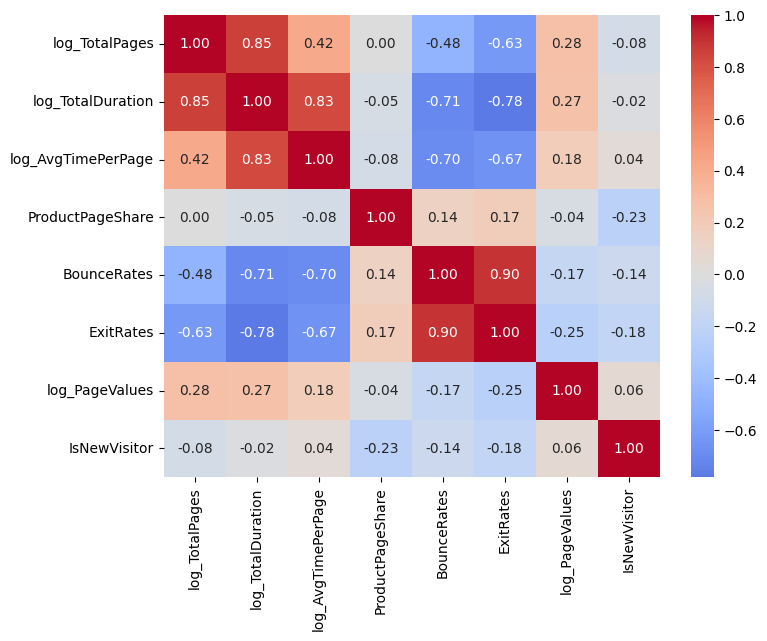

In [4]:
print(CLUSTER_FEATURES)
X = get_cluster_matrix(feats)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax); plt.show()

### Scaling
K-Means is distance-based, so every feature is standardised to mean 0 / std 1.

In [5]:
X_scaled, scaler = scale_features(X)
pd.DataFrame(X_scaled, columns=X.columns).describe().loc[['mean','std']].round(3)

,log_TotalPages,log_TotalDuration,log_AvgTimePerPage,ProductPageShare,BounceRates,ExitRates,log_PageValues,IsNewVisitor
mean,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
